# Lab 2: Geostrophic Adjustment

**Driving question:** How does geostrophic balance get established from some initial disturbance, and what governs the nature of this *geostrophic adjustment*?

**Your task:** This notebook already contains a complete model that simulates geostrophic adjustment and horizontal propagating shallow water waves by numerically solving (i.e., integrating) the linearized shallow water equations. Your job is to:
1. Use this model to run experiments by modifying key parameters
2. Create visuals that help you demonstrate the sensitivities of geostrophic adjustment to those changes
3. Write up interpretations in markdown boxes at the bottom of this notebook.

More below on each of these tasks...

**Due date:** complete this notebook and push it to your repo by 11:59 PM, Friday Sept. 18th.

## Model overview

This model numerically solves the shallow water equations of motion for a one-dimensional disturbance on an $f$-plane. Wave propagation and divergent motion manifest in the $x$-dimension. The $v$-wind oscillates through Coriolis deflection, but with no divergence. In this sense, there is no propagation in $y$. The model is linearized: we will neglect nonlinear advection, which significantly simplifies solutions. The equations that the model solves are as follows:

$$
\frac{\partial u}{\partial t}-f_0v=-g\frac{\partial h}{\partial x},
$$

$$
\frac{\partial v}{\partial t}+f_0u=0,
$$

$$
\frac{\partial h}{\partial t}+H\frac{\partial u}{\partial x}=0.
$$

As in class, $u$ and $v$ are the perturbation velocity components, $h$ is the perturbation layer height, $H$ is the base state layer depth, $f_0$ is the Coriolis parameter, and $g$ is gravity.

To kick off disturbances, the model is initialized with an initial Gaussian height anomaly and resting initial-state velocity:

$$
h(0,x)=h_0\exp\left[-\frac{x^2}{2L_0^2}\right],
\quad u(0,x)=v(0,x)=0.
$$

This initial height perturbation requires two input parameters:
1. $L_0$ assumed horizontal length scale (i.e., Gaussian width)
2. $h_0$ amplitude

## Model parameters that can remain unmodified

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Note: most settings below are just the default values.
# Many can be overridden when the model is called further down the notebook.

# Physical constants
G = 9.81                         # m s^-2
OMEGA = 7.2921159e-5             # Earth's rotation rate, s^-1
H = 250.0                        # base state layer depth, m

# Spatial grid
DOMAIN_LENGTH = 20_000_000.0     # 20,000 km
NX = 1000                        # Number of grid points
DX = DOMAIN_LENGTH / NX          # Grid spacing, m
X = (np.arange(NX) - NX // 2) * DX # X-grid, m

# Initial Gaussian disturbance
L_0 = 600_000.0                  # Length scale, i.e., Gaussian width, m
h_0 = 10.0                       # Initial disturbance amplitude, m

# Time integration
DT = 120.0                       # Time step, s
STOP_TIME = 48.0 * 3600.0        # Experiment duration, s
SAVE_EVERY = 5                   # Save output every x time steps

# Print some basic information about the simulation
print(f"Grid spacing: {DX / 1000:.1f} km")
print(f"Grid size: {NX * DX / 1000:.0f} km")
print(f"Experiment duration: {STOP_TIME / 3600:.0f} h")
print(f"Time step: {DT / 60:.1f} min")
print()

# Print some default settings
print(f"Initial disturbance width L_0: {L_0 / 1000:.0f} km")
print(f"Initial disturbance amplitude h_0: {h_0} m")

Grid spacing: 20.0 km
Grid size: 20000 km
Experiment duration: 48 h
Time step: 2.0 min

Initial disturbance width L_0: 600 km
Initial disturbance amplitude h_0: 10.0 m


## Model engine

### Support functions

In [2]:
# Calculate the Coriolis parameter f_0
def coriolis_parameter(latitude_degrees):
    latitude_radians = np.deg2rad(latitude_degrees)
    return 2.0 * OMEGA * np.sin(latitude_radians)

# Calculate the x-gradient using a second-order centered difference scheme
# with periodic boundary conditions
def centered_gradient(field, dx=DX):
    return (np.roll(field, -1, axis=-1) - np.roll(field, 1, axis=-1)) / (2.0 * dx)

# Initially resting fluid with a centered Gaussian height anomaly
def initial_conditions(amplitude=h_0, width=L_0, x=X):
    h = amplitude * np.exp(-0.5 * (x / width) ** 2)
    u = np.zeros_like(h)
    v = np.zeros_like(h)
    return u, v, h

### Main driver functions

In [3]:
# Advance the fields to the next time step with a centered half/full/half-step update
def advance_one_step(u0, v0, h0, dt, f_0, g=G, mean_depth=H, dx=DX):

    # This is where our equations of motion are implemented
    # 
    # The centered half/full/half-step update is a numerical integration scheme that
    # updates the velocity and height fields in a staggered manner.
    # 
    # The first half-step updates the velocity fields using the current height field,
    # then the full step updates the height field using the updated velocity fields,
    # and finally, the second half-step updates the velocity fields again using the
    # new height field.
    # 
    # This approach helps maintain numerical stability and accuracy in the solution.

    du_dt = f_0 * v0 - g * centered_gradient(h0, dx)
    u_half = u0 + 0.5 * dt * du_dt

    dv_dt = -f_0 * u_half
    dh_dt = -mean_depth * centered_gradient(u_half, dx)

    v1 = v0 + dt * dv_dt
    h1 = h0 + dt * dh_dt
    u1 = u_half + 0.5 * dt * (f_0 * v1 - g * centered_gradient(h1, dx))

    return u1, v1, h1

# Integrate one experiment and return a dictionary of saved NumPy arrays
def integrate_case(
    f_0,                   # Coriolis setting (required argument)
    amplitude=h_0,         # Perturbation amplitude (optional argument with a default setting if blank)
    width=L_0,             # Length scale (optional argument)
    stop_time=STOP_TIME,   # Experiment duration (optional argument)
    dt=DT,                 # Time step (optional argument)
    save_every=SAVE_EVERY, # Save output every x time steps (optional argument)
):
    # The model parameters for a given integration are established by the arguments passed
    # into the function. As the comments above imply, a mix of required and optional
    # arguments are used. Optional arguments are those that have default values provided
    # in the function definition. As written, f_0 is a required input, while all other
    # parameters use default values unless explicitly specified in the function call.

    # Establish model initial state
    u, v, h = initial_conditions(amplitude=amplitude, width=width)

    n_steps = int(round(stop_time / dt))

    # Main model time loop
    # Variables are saved in lists at specified intervals (using the % "modulo" operator)
    times, u_saved, v_saved, h_saved = [], [], [], []
    for step in range(n_steps + 1):
        if step % save_every == 0:
            times.append(step * dt)
            u_saved.append(u.copy())
            v_saved.append(v.copy())
            h_saved.append(h.copy())

        if step < n_steps:
            u, v, h = advance_one_step(u, v, h, dt, f_0)

    # Return a dictionary of saved NumPy arrays and parameter settings
    return {
        "time": np.asarray(times),
        "x": X.copy(),
        "u": np.asarray(u_saved),
        "v": np.asarray(v_saved),
        "h": np.asarray(h_saved),
        "f_0": float(f_0),
        "amplitude": float(amplitude),
        "width": float(width),
    }

## YOUR TASK STARTS HERE

The function `integrate_case()` in the above code block is the main model *driver function.* As in most atmospheric models, the driver is the parent function that calls all other tasks to run the model. In our model, this driver function does the following:
1. Establishes the parameters for the model run
2. Creates the model initial state
3. Loops over time to integrate the equations
4. Writes out the model output as a dictionary

As noted in the comments inside that function, the parameters for a given model run are established through the function's arguments. Only one argument ($f_0$) is required, while all others are set to default values unless specified otherwise when the function is called.

Your task is to run the model for a set of parameter modifications across two key dimensions: $f_0$ and $L_0$ (*width* in the function call). Compare at least four values of $f_0$, including zero, while holding $L_0$ fixed. Separately, compare at least four values of $L_0$ at a fixed, nonzero value of $f_0$. You may reuse a common baseline experiment. Keep track of any parameters you change and hold constant.

Examples of how to run the model by calling this function are provided below. In the loop example, the code populates `lists` and `dictionaries`, which are two distinct powerful ways to store collections of information. See [this page](https://www.geeksforgeeks.org/python/difference-between-list-and-dictionary-in-python/) for a quick overview of their usage and differences.

### Example run code

I suggest leaving this code unchanged for reference, and writing your own in the block below (copying anything that may be helpful from this one).

In [4]:
# Example model run for a given latitude and f_0-setting
# All other settings are left to default values
latitude = 15.0
f_0 = coriolis_parameter(latitude)
single_run_f15deg = integrate_case(f_0)
# Print the dictionary keys and some parameter values
print(single_run_f15deg.keys())
print(f"Coriolis parameter: {single_run_f15deg['f_0']}")
print(f"h_0: {single_run_f15deg['amplitude']}")
print(f"L_0: {single_run_f15deg['width']}")
print()

# Example model run for a given latitude and f_0-setting with a smaller L_0 value
single_run_f15_modL0 = integrate_case(f_0, width=100000.0)
# Print the dictionary keys and some parameter values
print(single_run_f15_modL0.keys())
print(f"Coriolis parameter: {single_run_f15_modL0['f_0']}")
print(f"h_0: {single_run_f15_modL0['amplitude']}")
print(f"L_0: {single_run_f15_modL0['width']}")
print()

# Use a loop to iteratively run a set of 4 experiments and store their parameter settings
case_names = [] # initialize a list
run_params = [] # initialize a list
runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for lat in [0, 15.0, 35.0, 60.0]:
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N"
    print(f"Integrating {case_label} ...")
    case_names.append(case_label)
    run_params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": L_0})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=L_0)

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 600000.0

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 100000.0

Integrating 0°N ...
Integrating 15.0°N ...
Integrating 35.0°N ...
Integrating 60.0°N ...


### Your new run code

In [5]:
#Compare different values of f_0
label = []
params = []
runs = {}
for lat in [0, 15, 30, 45, 60, 75]:
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N"
    print(f"Integrating lat={case_label} ...")
    label.append(case_label)
    params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": L_0})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=L_0)

#Compare different values of L_0
f = coriolis_parameter(45)    
for L_0 in [200000, 400000, 600000, 800000]:
    case_label = f"L_0={L_0 / 1000:.0f} km"
    print(f"Integrating {case_label} ...")
    label.append(case_label)
    params.append({"label": case_label, "latitude": 15.0, "f_0": f, "amplitude": h_0, "width": L_0})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=L_0)

Integrating lat=0°N ...
Integrating lat=15°N ...
Integrating lat=30°N ...
Integrating lat=45°N ...
Integrating lat=60°N ...
Integrating lat=75°N ...
Integrating L_0=200 km ...
Integrating L_0=400 km ...
Integrating L_0=600 km ...
Integrating L_0=800 km ...


## Plots

The plotting task for this assignment provides a lot of latitude (zing). But your visuals should accomplish the following:
- Provide an adequate sense of how the geostrophic adjustment (GA) process works and evolves in general in this model by showing the evolution of height and both velocity components for a rotating (i.e., $f_0\ne0$) experiment
- Demonstrate how the GA process differs as a function of varied $f_0$ and $L_0$ (it is probably ideal to depict those sensitivities separately).

Also, in all plots, be sure to label axes with units and identify cases (any parameter settings as needed) and times. Use consistent axis limits or color scales where practical when direct comparisons are important.

Here are some example plot ideas, which may be helpful.
- multipanel for a single simulation: a set of snapshots of the perturbation height and wind fields at several times through the duration of a given simulation
- multipanel for multiple simulations: plot a given variable at multiple time steps for a given simulation in each panel
- Hovmöller diagrams (time vs. $x$) with a given perturbation variable shaded, which could be shown as a multipanel for different variables or different simulations (using the same variable)

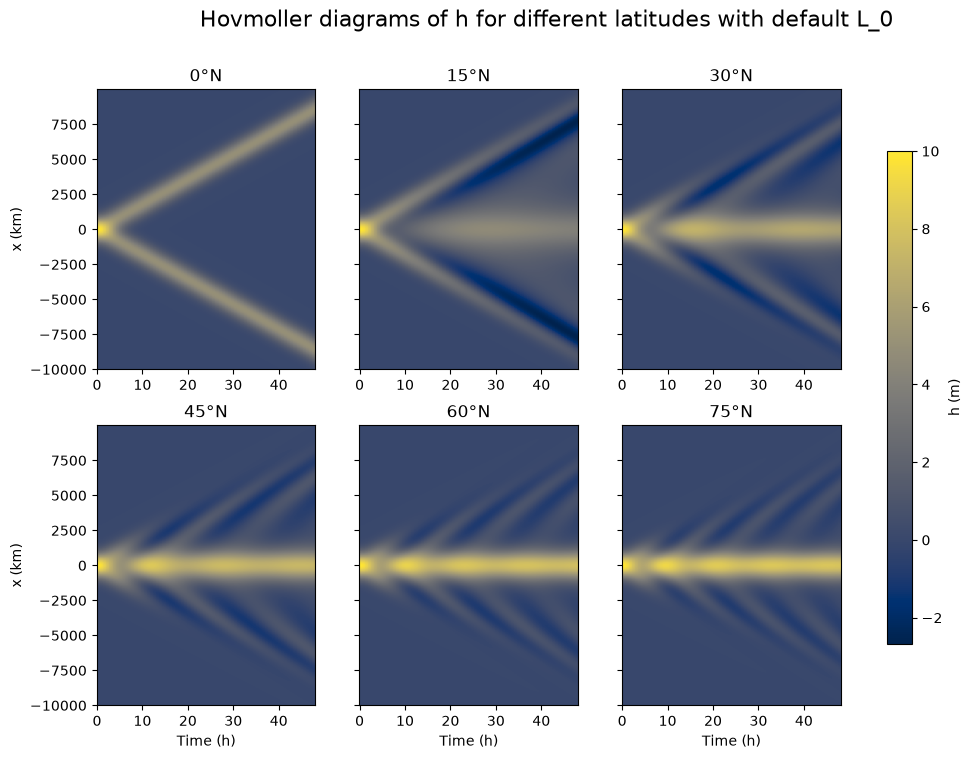

In [27]:
#Make Hovmoller diagrams for h at different latitudes with constant L_0 (comparing different values of f_0)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
ax1, ax2, ax3 = axes[0]
ax4, ax5, ax6 = axes[1]
vmin = np.min([np.min(runs["0°N"]["h"][:, :]),np.min(runs["15°N"]["h"][:, :]),np.min(runs["30°N"]["h"][:, :]),np.min(runs["45°N"]["h"][:, :]),np.min(runs["60°N"]["h"][:, :]),np.min(runs["75°N"]["h"][:, :])])
vmax = np.max([np.max(runs["0°N"]["h"][:, :]),np.max(runs["15°N"]["h"][:, :]),np.max(runs["30°N"]["h"][:, :]),np.max(runs["45°N"]["h"][:, :]),np.max(runs["60°N"]["h"][:, :]),np.max(runs["75°N"]["h"][:, :])])


im1 = ax1.pcolormesh(runs["0°N"]["time"] / 3600, runs["0°N"]["x"] / 1000, runs["0°N"]["h"][:, :].T, vmin=vmin, vmax=vmax, cmap='cividis')
ax2.pcolormesh(runs["15°N"]["time"] / 3600, runs["15°N"]["x"] / 1000, runs["15°N"]["h"][:, :].T, vmin=vmin, vmax=vmax, cmap='cividis')
ax3.pcolormesh(runs["30°N"]["time"] / 3600, runs["30°N"]["x"] / 1000, runs["30°N"]["h"][:, :].T, vmin=vmin, vmax=vmax, cmap='cividis')
ax4.pcolormesh(runs['45°N']["time"] / 3600, runs["45°N"]["x"] / 1000, runs["45°N"]["h"][:, :].T, vmin=vmin, vmax=vmax, cmap='cividis')
ax5.pcolormesh(runs["60°N"]["time"] / 3600, runs["60°N"]["x"] / 1000, runs["60°N"]["h"][:, :].T, vmin=vmin, vmax=vmax, cmap='cividis')
ax6.pcolormesh(runs["75°N"]["time"] / 3600, runs["75°N"]["x"] / 1000, runs["75°N"]["h"][:, :].T, vmin=vmin, vmax=vmax, cmap='cividis')

ax1.set_title("0°N")
ax2.set_title("15°N")
ax3.set_title("30°N")       
ax4.set_title("45°N")
ax5.set_title("60°N")   
ax6.set_title("75°N")

ax1.set_ylabel("x (km)")
ax4.set_ylabel("x (km)")

ax4.set_xlabel("Time (h)")
ax5.set_xlabel("Time (h)")
ax6.set_xlabel("Time (h)")

ax2.set_yticklabels([])
ax3.set_yticklabels([])
ax5.set_yticklabels([])
ax6.set_yticklabels([])

fig.suptitle('Hovmoller diagrams of h for different latitudes with default L_0', fontsize=16)
fig.colorbar(im1, ax=axes.ravel().tolist(), label='h (m)', orientation='vertical', shrink=0.8)

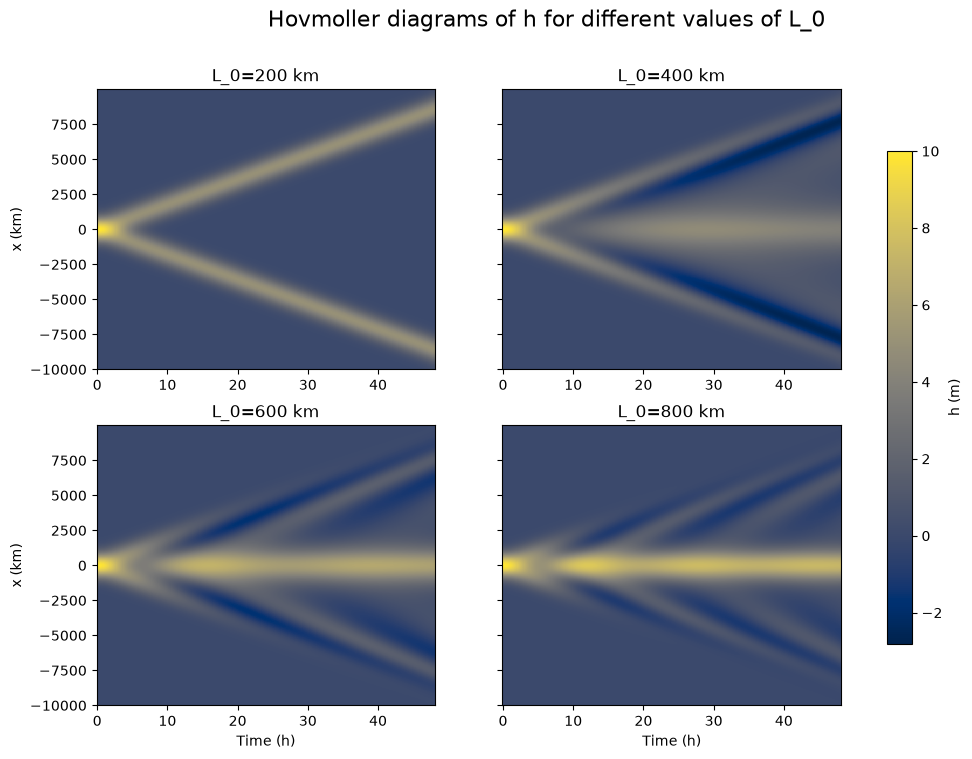

In [26]:
#Now, do the same but for different values of L_0 at a constant latitude
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax1, ax2 = axes[0]
ax3, ax4 = axes[1]
vmin = np.min([np.min(runs["L_0=200 km"]["h"][:, :]), np.min(runs["L_0=400 km"]["h"][:, :]), np.min(runs["L_0=600 km"]["h"][:, :]), np.min(runs["L_0=800 km"]["h"][:, :])])
vmax = np.max([np.max(runs["L_0=200 km"]["h"][:, :]), np.max(runs["L_0=400 km"]["h"][:, :]), np.max(runs["L_0=600 km"]["h"][:, :]), np.max(runs["L_0=800 km"]["h"][:, :])])


im1 = ax1.pcolormesh(runs["L_0=200 km"]["time"] / 3600, runs["0°N"]["x"] / 1000, runs["0°N"]["h"][:, :].T, vmin=vmin, vmax=vmax, cmap='cividis')
ax2.pcolormesh(runs["L_0=400 km"]["time"] / 3600, runs["15°N"]["x"] / 1000, runs["15°N"]["h"][:, :].T, vmin=vmin, vmax=vmax, cmap='cividis')
ax3.pcolormesh(runs["L_0=600 km"]["time"] / 3600, runs["30°N"]["x"] / 1000, runs["30°N"]["h"][:, :].T, vmin=vmin, vmax=vmax, cmap='cividis')
ax4.pcolormesh(runs['L_0=800 km']["time"] / 3600, runs["45°N"]["x"] / 1000, runs["45°N"]["h"][:, :].T, vmin=vmin, vmax=vmax, cmap='cividis')

ax1.set_title("L_0=200 km")
ax2.set_title("L_0=400 km")
ax3.set_title("L_0=600 km")       
ax4.set_title("L_0=800 km")


ax1.set_ylabel("x (km)")
ax3.set_ylabel("x (km)")

ax3.set_xlabel("Time (h)")
ax4.set_xlabel("Time (h)")

ax2.set_yticklabels([])
ax4.set_yticklabels([])

fig.suptitle('Hovmoller diagrams of h for different values of L_0', fontsize=16)
fig.colorbar(im1, ax=axes.ravel().tolist(), label='h (m)', orientation='vertical', shrink=0.8)

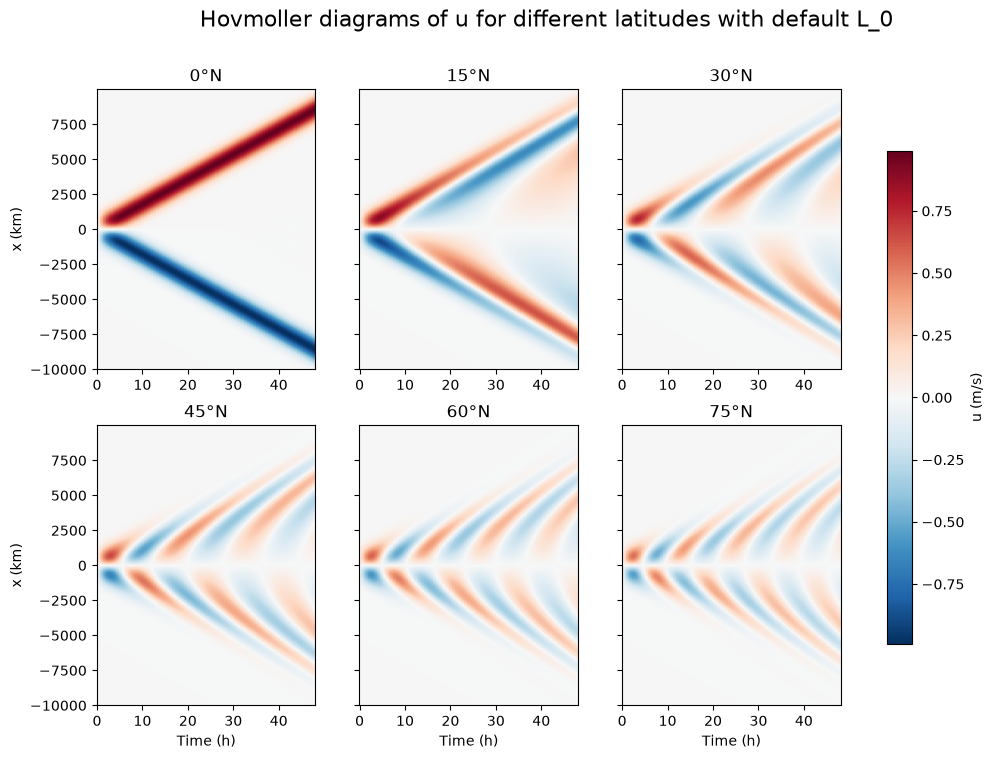

In [20]:
#Now, do the same but showing u for different values of f_0 at a constant L_0
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
ax1, ax2, ax3 = axes[0]
ax4, ax5, ax6 = axes[1]
vmin = np.min([np.min(runs["0°N"]["u"][:, :]),np.min(runs["15°N"]["u"][:, :]),np.min(runs["30°N"]["u"][:, :]),np.min(runs["45°N"]["u"][:, :]),np.min(runs["60°N"]["u"][:, :]),np.min(runs["75°N"]["u"][:, :])])
vmax = np.max([np.max(runs["0°N"]["u"][:, :]),np.max(runs["15°N"]["u"][:, :]),np.max(runs["30°N"]["u"][:, :]),np.max(runs["45°N"]["u"][:, :]),np.max(runs["60°N"]["u"][:, :]),np.max(runs["75°N"]["u"][:, :])])

im1 = ax1.pcolormesh(runs["0°N"]["time"] / 3600, runs["0°N"]["x"] / 1000, runs["0°N"]["u"][:, :].T, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax2.pcolormesh(runs["15°N"]["time"] / 3600, runs["15°N"]["x"] / 1000, runs["15°N"]["u"][:, :].T, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax3.pcolormesh(runs["30°N"]["time"] / 3600, runs["30°N"]["x"] / 1000, runs["30°N"]["u"][:, :].T, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax4.pcolormesh(runs['45°N']["time"] / 3600, runs["45°N"]["x"] / 1000, runs["45°N"]["u"][:, :].T, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax5.pcolormesh(runs["60°N"]["time"] / 3600, runs["60°N"]["x"] / 1000, runs["60°N"]["u"][:, :].T, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax6.pcolormesh(runs["75°N"]["time"] / 3600, runs["75°N"]["x"] / 1000, runs["75°N"]["u"][:, :].T, vmin=vmin, vmax=vmax, cmap='RdBu_r')

ax1.set_title("0°N")
ax2.set_title("15°N")
ax3.set_title("30°N")       
ax4.set_title("45°N")
ax5.set_title("60°N")   
ax6.set_title("75°N")

ax1.set_ylabel("x (km)")
ax4.set_ylabel("x (km)")

ax4.set_xlabel("Time (h)")
ax5.set_xlabel("Time (h)")
ax6.set_xlabel("Time (h)")

ax2.set_yticklabels([])
ax3.set_yticklabels([])
ax5.set_yticklabels([])
ax6.set_yticklabels([])

fig.suptitle('Hovmoller diagrams of u for different latitudes with default L_0', fontsize=16)
fig.colorbar(im1, ax=axes.ravel().tolist(), label='u (m/s)', orientation='vertical', shrink=0.8)

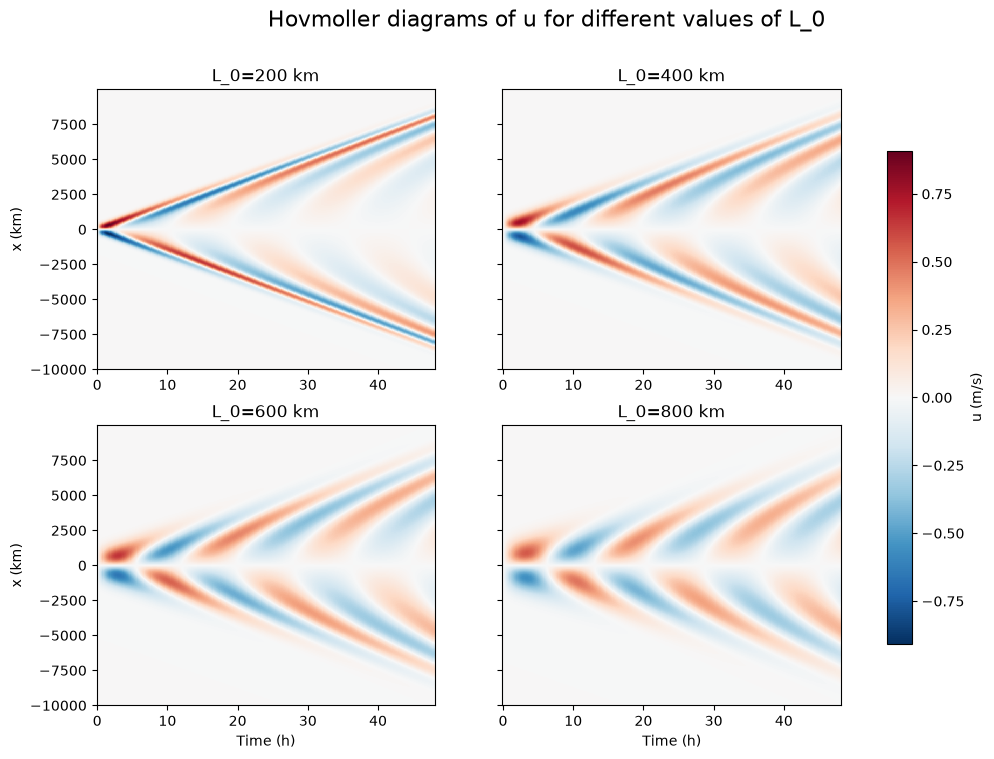

In [21]:
#Now, do the same for u but for different values of L_0 at a constant latitude
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax1, ax2 = axes[0]
ax3, ax4 = axes[1]
vmin = np.min([np.min(runs["L_0=200 km"]["u"][:, :]), np.min(runs["L_0=400 km"]["u"][:, :]), np.min(runs["L_0=600 km"]["u"][:, :]), np.min(runs["L_0=800 km"]["u"][:, :])])
vmax = np.max([np.max(runs["L_0=200 km"]["u"][:, :]), np.max(runs["L_0=400 km"]["u"][:, :]), np.max(runs["L_0=600 km"]["u"][:, :]), np.max(runs["L_0=800 km"]["u"][:, :])])

im1 = ax1.pcolormesh(runs["L_0=200 km"]["time"] / 3600, runs["L_0=200 km"]["x"] / 1000, runs["L_0=200 km"]["u"][:, :].T, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax2.pcolormesh(runs["L_0=400 km"]["time"] / 3600, runs["L_0=400 km"]["x"] / 1000, runs["L_0=400 km"]["u"][:, :].T, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax3.pcolormesh(runs["L_0=600 km"]["time"] / 3600, runs["L_0=600 km"]["x"] / 1000, runs["L_0=600 km"]["u"][:, :].T, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax4.pcolormesh(runs["L_0=800 km"]["time"] / 3600, runs["L_0=800 km"]["x"] / 1000, runs["L_0=800 km"]["u"][:, :].T, vmin=vmin, vmax=vmax, cmap='RdBu_r')

ax1.set_title("L_0=200 km")
ax2.set_title("L_0=400 km")
ax3.set_title("L_0=600 km")       
ax4.set_title("L_0=800 km")


ax1.set_ylabel("x (km)")
ax3.set_ylabel("x (km)")

ax3.set_xlabel("Time (h)")
ax4.set_xlabel("Time (h)")

ax2.set_yticklabels([])
ax4.set_yticklabels([])

fig.suptitle('Hovmoller diagrams of u for different values of L_0', fontsize=16)
fig.colorbar(im1, ax=axes.ravel().tolist(), label='u (m/s)', orientation='vertical', shrink=0.8)

In [30]:
# import matplotlib.animation as animation
# from IPython.display import HTML

# def animate(t):
#     wv.set_ydata(runs[run]["h"][t, :])
#     title_text.set_text(f"{run}: Frame: {t}")
#     return wv, title_text

# animations = []

# for run in runs:
#     fig, ax = plt.subplots()
#     wv, = ax.plot(runs[run]["x"] / 1000, runs[run]["h"][0, :])
#     ax.set_xlabel('x (km)')
#     ax.set_ylabel('h (m)')
#     title_text = ax.set_title(f"{run}:Frame: 0")
#     ani =  animation.FuncAnimation(fig, animate, frames=len(runs[run]["time"]), interval=100)
#     animations.append(ani)
    
#     #display(HTML(ani.to_jshtml()))  ##This is commented out so I can upload to GitHub, it was too large otherwise
#     plt.close(fig) 


## Diagnostics

For each experiment, diagnose numerical values of $L_D$, $Bu$, and $Ro$ in a table or clearly labeled output. These will be useful for your interpretations below.
$$
L_D=\frac{\sqrt{gH}}{|f_0|},\qquad
Bu=\left(\frac{L_D}{L_0}\right)^2,\qquad
Ro=\frac{U}{|f_0|L_0},\qquad
U=\max_{x,t}\sqrt{u^2+v^2}.
$$
where $U$ is the maximum modeled speed over all saved positions and times; use consistent units in the calculations and be sure to label any units used as needed. Note that some of these metrics are invalid for $f_0=0$ (you can report NaN for those).

In [29]:
#Define the above functions, then print out the values for each run
def L_D(f_0):
    if f_0 == 0:
        return np.nan 
    L_D = np.sqrt(G * H) / np.abs(f_0)
    return L_D

def B_u(L_D, L_0):
    B_u = (L_D / L_0) ** 2
    return B_u

def U(u, v):
    U = np.sqrt(np.max(u)**2 + np.max(v)**2)
    return U

def R_o(U, f_0, L_0):
    if f_0 == 0:
        return np.nan
    Ro = U / (np.abs(f_0) * L_0)
    return Ro

for run in runs:
    f_0_run = runs[run]['f_0']
    L_0_run = runs[run]['width']
    u_run = runs[run]['u']
    v_run = runs[run]['v']

    runs[run]['L_D'] = L_D(f_0_run)
    runs[run]['B_u'] = B_u(runs[run]['L_D'], L_0_run)
    runs[run]['U'] = U(u_run, v_run) 
    runs[run]['R_o'] = R_o(runs[run]['U'], f_0_run, L_0_run)

    print(f"For run: {run}")
    print(f"L_D: {runs[run]['L_D']/1000:.4f} km")
    print(f"B_u: {runs[run]['B_u']:.4f}")
    print(f"U: {runs[run]['U']:.4f} m/s")
    print(f"R_o: {runs[run]['R_o']:.4f}")



For run: 0°N
L_D: nan km
B_u: nan
U: 0.9904 m/s
R_o: nan
For run: 15°N
L_D: 1311.9725 km
B_u: 4.7813
U: 1.1877 m/s
R_o: 0.0524
For run: 30°N
L_D: 679.1269 km
B_u: 1.2811
U: 1.2303 m/s
R_o: 0.0281
For run: 45°N
L_D: 480.2152 km
B_u: 0.6406
U: 1.1662 m/s
R_o: 0.0188
For run: 60°N
L_D: 392.0941 km
B_u: 0.4270
U: 1.0960 m/s
R_o: 0.0145
For run: 75°N
L_D: 351.5420 km
B_u: 0.3433
U: 1.0491 m/s
R_o: 0.0124
For run: L_0=200 km
L_D: 480.2152 km
B_u: 5.7652
U: 1.1722 m/s
R_o: 0.0568
For run: L_0=400 km
L_D: 480.2152 km
B_u: 1.4413
U: 1.2342 m/s
R_o: 0.0299
For run: L_0=600 km
L_D: 480.2152 km
B_u: 0.6406
U: 1.1662 m/s
R_o: 0.0188
For run: L_0=800 km
L_D: 480.2152 km
B_u: 0.3603
U: 1.0602 m/s
R_o: 0.0129


## Interpretations

Address each of the following prompts in the markdown cell below them. In each response, be specific and reference your plots to support your points.

1. For a rotating experiment (i.e., $f_0 \ne 0$), describe the geostrophic adjustment process: explain what initiates motion, how the height and velocity fields subsequently evolve, and what evidence suggests that the central disturbance approaches geostrophic balance. Distinguish the central remnant from the outward-propagating waves.

Motion is initiated by the imbalance contained in the intial perturbation. The height anomaly is being pulled down by gravity, which initiates motion as some form of gravity wave. Because there is rotation, this is not a pure gravity wave, but rather an inertial gravity wave. The central remnant is easily distinguishable from the outward-propagating waves due to the stationary (in the horizontal) nature of the peak height. The inertial gravity waves transmit the peak magnitudes towards the edges of the simulation.

The frequency of these waves depends on the dispersion relation covered in class, with higher frequencies visible when rotational effects are more pronounces (i.e. at higher latitudes). This can be seen in the Hovmoller diagrams for u, where alternations between positive and negative u become much more frequent as rotational effects become more dominant. The outward-propagating waves tend to decrease in amplitude over time; this occurs much quicker at higher latitudes. This makes sense, as the Coriolis force will deflect winds from pure outward motion, reducing the mass in a pure gravitational oscillation. 

There is evidence that the central disturbance generally approaches geostrophic balance, as the Rossby numbers for each rotating simulation are well below 1. Additionally, the center begins to level out around some height, indicating it is reaching equilibrium.

2. Discuss the effects of changing $f_0$ and $L_0$ separately. What changes in the evolution and the remnant height anomaly at the center? Include the nonrotating case in your discussion. Incorporate $Ro$, $L_D$, and $Bu$ into your interpretations.

As f_0 increases, the height anomaly at the center reaches equilibrium at a higher anomaly. This is because higher Coriolis leads to stronger deflection of winds in the y-direction, trapping mass at the center as compared to fully x-divergent flow. This is evident in the nonrotating case, as the height anomaly in the center completely flattens and a wave of higher heights splits off evenly away from the center.

Changing to a narrower width produces a similar effect to reducing the Coriolis force, as the height anomaly drops much faster and reaches apparent equilibrium at a much lower height. It almost appears that there is more resistance to mass spreading out when the intial width of the disturbance is larger.

The Burger Number Bu is a good summation of the above effects, as it is highest when Coriolis is small or widths are narrow. Since L is not changing, it diagnoses the relative magnitude of the Rossby Radius of Deformation, Ld, which compares the effects of the PGF and Coriolis. When it is high, gravity waves are faster; when it is low, gravity waves are slower. This is subtly evident in the experiment, but is difficult to view as gravity waves diminish in magnitude much quicker when the Burger Number is lower.

3. What's something surprising you learned or something you understand better now after this lab, either related to dynamics, modeling, or programming?

I learned how to create a playable animation within a jupyter notebook, which in turn helped me better visualize atmospheric waves. I was surprised at how strong the central remnant remained in most of the cases, especially as instinct suggested the anomaly should flatten out completely to reach equilibrium. This lab also helped me to better connect some of the wave property things from PDE like the dispersion relation and phase speed to dynamics; we covered them briefly in undergrad dynamics, but it wasn't the most clear at the time.